# EPInformer-seq Testing: 1024-bp Enhancer Activity (per-cell) at the SORT1 Locus

`EPInformer-seq` is a sequence encoder that takes a 1024-bp DNA window and
returns a single scalar: the **linear √(DNase × H3K27ac)** signal in RPM
space — a combined chromatin-accessibility-times-active-mark readout
calibrated against ENCODE H3K27ac peak summits. Chorus ships per-cell
weights for 11 Roadmap cell lines (K562, GM12878, HepG2, A549, HeLa,
HMEC, HSMM, HUVEC, NHEK, NHLF, H1).

The scalar is the peak max of each per-bp channel over the **central
256 bp** of the 1024-bp window (positions 384–639), combined via
`sqrt(max(DNase) × max(H3K27ac))`. Surrounding context still informs the
model's softmax+count, just isn't part of the aggregation slice — this
matches the background CDF builder so percentile lookups stay consistent.

The chorus track is exposed as **assay_type `Enhancer_H3K27ac_DNase`** — one track ID
per cell, e.g. `Enhancer_H3K27ac_DNase:HepG2`.

This notebook is the end-to-end smoke test for the oracle. It walks the
[rs12740374](https://www.ncbi.nlm.nih.gov/snp/rs12740374) locus on chr1 —
the canonical SORT1/CELSR2 GWAS variant that creates a new C/EBP-α binding
site and turns a quiescent hepatocyte enhancer into an active one — and
exercises every feature added to the oracle this session:

1. Instantiate + load default checkpoint (K562).
2. Wild-type prediction on genomic coordinates.
3. Variant-effect prediction (ref vs. alt).
4. Cross-cell discovery — loop over all 11 cells without re-instantiating.
5. Saturation mutagenesis (ISM) over the central 256 bp of the 1024-bp window.
6. Cross-oracle comparison vs. ChromBPNet DNase (and optionally
   AlphaGenome) in HepG2.

**Runtime**: ~5–10 min on Apple Silicon (MPS) or NVIDIA (CUDA).
**Prereqs**: `chorus setup --oracle epinformerseq` + per-cell weights
under `~/.chorus/downloads/epinformerseq/` (auto-fetched from the HF
mirror on first use) + background CDFs at
`~/.chorus/backgrounds/epinformerseq_pertrack.npz`.

## Setup

In [1]:
import os
# Allow conda-env subprocess imports (env validation runs `python -c "import torch"`
# inside chorus-epinformerseq; libomp.dylib gets loaded from both envs on macOS
# and would otherwise abort with `OMP: Error #15`). This is the canonical
# macOS workaround and is safe for inference-only workloads.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import warnings
warnings.filterwarnings(
    'ignore',
    message=".*padding='same'.*",
)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import chorus
from chorus.utils import get_genome, extract_sequence
from chorus.analysis.normalization import PerTrackNormalizer
from chorus.oracles.epinformerseq_source.globals import (
    EPINFORMERSEQ_AVAILABLE_CELLTYPES,
)

ASSAY = 'Enhancer_H3K27ac_DNase'  # the chorus assay_type for this oracle
print('chorus version:', chorus.__version__)
print('assay        :', ASSAY)


chorus version: 0.5.6
assay        : Enhancer_H3K27ac_DNase


In [2]:
# Reference genome (auto-downloads to ~/.chorus/genomes if missing).
genome_path = get_genome('hg38')
print('genome:', genome_path)


genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa


## 1. Create the EPInformer-seq oracle

We load the default `K562` checkpoint first. `use_environment=True` runs
the model inside the `chorus-epinformerseq` conda env (PyTorch + a few
bio utilities) — chorus spawns and manages the subprocess for us.


In [3]:
oracle = chorus.create_oracle(
    'epinformerseq',
    use_environment=True,
    cell_type='K562',
    reference_fasta=str(genome_path),
)
oracle.load_pretrained_model()

print('loaded =', oracle.loaded)
print('assay_id =', oracle.assay_id)
print('window =', oracle.sequence_length, 'bp')
print('available cell types =', EPINFORMERSEQ_AVAILABLE_CELLTYPES)
print('available assays =', oracle.list_assay_types())


2026-05-28 20:04:43,885 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 20:04:45,654 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


2026-05-28 20:04:51,610 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


loaded = True
assay_id = Enhancer_H3K27ac_DNase:K562
window = 1024 bp
available cell types = ['K562', 'GM12878', 'HepG2', 'A549', 'HeLa', 'HMEC', 'HSMM', 'HUVEC', 'NHEK', 'NHLF', 'H1']
available assays = ['Enhancer_H3K27ac_DNase', 'Enhancer_DNase', 'Enhancer_H3K27ac']


## 2. Wild-type activity at the SORT1 enhancer

We score a 1024-bp window centred on rs12740374 (chr1:109,274,968 in hg38,
1-based). The variant is at the dead centre of the model's input. The
returned scalar is **linear √(max DNase × max H3K27ac)** over the central
256 bp in RPM-space (not log₂); we look it up against the precomputed
genome-wide baseline CDF.

In [4]:
VARIANT_POS = 109_274_968  # 1-based, hg38
HALF = 512                 # 1024-bp window for the per-cell v2 model
REGION_START = VARIANT_POS - HALF + 1   # 1-based inclusive
REGION_END   = VARIANT_POS + HALF       # 1-based inclusive
TRACK_K562 = f'{ASSAY}:K562'
print(f'region = chr1:{REGION_START}-{REGION_END}  ({REGION_END-REGION_START+1} bp)')
print(f'track  = {TRACK_K562}')

wt_pred = oracle.predict(
    ('chr1', REGION_START, REGION_END),
    [TRACK_K562],
)
wt_track = wt_pred[TRACK_K562]

wt_value = float(wt_track.values[0])
print(f'WT √(max DNase × max H3K27ac) [K562] = {wt_value:.4f}  (linear RPM, central 256 bp)')
print(f'  underlying max DNase × max H3K27ac = {wt_value**2:.4f}')

region = chr1:109274457-109275480  (1024 bp)
track  = Enhancer_H3K27ac_DNase:K562


WT √(max DNase × max H3K27ac) [K562] = 0.9036  (linear RPM, central 256 bp)
  underlying max DNase × max H3K27ac = 0.8165


In [5]:
# Convert to an activity %ile against the per-track CDF built from
# ~30k cCRE + TSS + random hg38 positions.
norm = PerTrackNormalizer()
assert norm.has_oracle('epinformerseq'), \
    'epinformerseq backgrounds not installed; run scripts/build_backgrounds_epinformerseq.py'

act_pct = norm.activity_percentile('epinformerseq', TRACK_K562, wt_value)
print(f'WT activity %ile (K562) = {act_pct:.3f}')
print(f'  ({100*act_pct:.1f} %% of background positions show LOWER activity)')


2026-05-28 20:04:55,238 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'epinformerseq': 11 tracks, CDFs: effect_cdfs, summary_cdfs


WT activity %ile (K562) = 0.729
  (72.9 %% of background positions show LOWER activity)


## 3. Variant effect — rs12740374 G>T

`predict_variant_effect` returns predictions for the reference and each
alternate allele. The `Enhancer_H3K27ac_DNase` layer is **signed**:
effect = ALT − REF, in linear √(DNase × H3K27ac) units.


In [6]:
ve = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_K562],
)
ref_val = float(ve['predictions']['reference'][TRACK_K562].values[0])
alt_val = float(ve['predictions']['alt_1'][TRACK_K562].values[0])
effect  = alt_val - ref_val
eff_pct = norm.effect_percentile('epinformerseq', TRACK_K562, effect)

pd.DataFrame([{
    'oracle': 'epinformerseq',
    'track': TRACK_K562,
    'ref_value': ref_val,
    'alt_value': alt_val,
    'signed_effect_linear': effect,
    'fold_change_alt_over_ref': alt_val / ref_val,
    'effect_pctile': eff_pct,
}])


,oracle,track,ref_value,alt_value,signed_effect_linear,fold_change_alt_over_ref,effect_pctile
0,epinformerseq,Enhancer_H3K27ac_DNase:K562,0.896004,0.974123,0.07812,1.087187,0.985951


> **Interpretation.** rs12740374 G→T is the SORT1 GWAS-LDL variant. The
> ALT allele creates a C/EBP-α binding site that opens chromatin in
> hepatocytes. K562 is *not* a hepatocyte line — we expect a small
> positive effect but the relevant signal will show up much more
> strongly in HepG2 (§4).


## 3.5 Wide-window variant (`variant='widewin'`) — DNase cut-site head

The oracle above is the **standard** 1024-bp model (read-coverage, combined
DNase × H3K27ac). chorus also ships a **wide-window** variant:

```python
chorus.create_oracle('epinformerseq', variant='widewin', cell_type='K562')
```

`PerCellProfileNetWide` takes a **2114-bp** input, runs it through the dilated
body, then crops the **central 1024 bp** for its heads — ChromBPNet-style
"valid" geometry, so every output base has a full real-sequence receptive
field. It is trained on **5′ DNase cut-sites** (motif-sensitive, sharper than
read coverage) and is **DNase-only** (the H3K27ac channel is a zero
placeholder), so score the `Enhancer_DNase` head — *not* the composite.
Per-cell genome-wide cut-site count-`r` is 0.53–0.87 (HepG2 0.682). Weights
live under `per_cell_widewin/` on the HF mirror
(`lucapinello/chorus-epinformerseq-v2`); the matching background is
`epinformerseq_widewin_pertrack.npz`, built with
`scripts/build_backgrounds_epinformerseq_v2_percell.py --variant widewin`.

At **rs12740374** the cut-site head resolves the variant **much more sharply**
than coverage: in K562 the DNase `log2fc` is **≈ +0.48** (widewin) vs **≈ +0.11**
(standard) — and the widewin effect lands **above the 99th percentile** of
background DNase variant effects for K562.


In [ ]:
# Wide-window (widewin) variant: PerCellProfileNetWide, 2114-bp input -> central
# 1024 crop, trained on 5' DNase cut-sites. DNase-only, so score Enhancer_DNase.
# use_environment=False runs the small (136K-param) model directly in this kernel.
oracle_ww = chorus.create_oracle(
    'epinformerseq', use_environment=False,
    cell_type='K562', variant='widewin', reference_fasta=str(genome_path),
)
oracle_ww.load_pretrained_model()
oracle_ww.assay = 'Enhancer_DNase'
oracle_ww.assay_id = 'Enhancer_DNase:K562'
print('widewin input window =', oracle_ww.sequence_length, 'bp')   # 2114

WW_HALF = oracle_ww.sequence_length // 2          # 1057
ve_ww = oracle_ww.predict_variant_effect(
    genomic_region=f'chr1:{VARIANT_POS - WW_HALF + 1}-{VARIANT_POS + WW_HALF}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=['Enhancer_DNase:K562'],
)
rw = float(ve_ww['predictions']['reference']['Enhancer_DNase:K562'].values[0])
aw = float(ve_ww['predictions']['alt_1']['Enhancer_DNase:K562'].values[0])

# Standard 1024-bp coverage DNase head for the same variant, as a baseline.
oracle.assay = 'Enhancer_DNase'
oracle.assay_id = 'Enhancer_DNase:K562'
ve_sd = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=['Enhancer_DNase:K562'],
)
rs_ = float(ve_sd['predictions']['reference']['Enhancer_DNase:K562'].values[0])
as_ = float(ve_sd['predictions']['alt_1']['Enhancer_DNase:K562'].values[0])
oracle.assay = ASSAY                               # reset for the cells below
oracle.assay_id = f'{ASSAY}:K562'

def _l2fc(r, a):
    return float(np.log2((a + 1.0) / (r + 1.0)))

# widewin variant-effect percentile uses its OWN background NPZ
# (epinformerseq_widewin_pertrack.npz; effect CDF is on |log2fc|).
norm_ww = PerTrackNormalizer()
ww_pct = (norm_ww.effect_percentile('epinformerseq_widewin', 'Enhancer_DNase:K562', _l2fc(rw, aw))
          if norm_ww.has_oracle('epinformerseq_widewin') else float('nan'))

pd.DataFrame([
    {'head': 'standard (1024 coverage)', 'ref': rs_, 'alt': as_, 'log2fc': _l2fc(rs_, as_),
     'effect_pctile': float('nan')},
    {'head': 'widewin (2114 cut-site)',  'ref': rw,  'alt': aw,  'log2fc': _l2fc(rw, aw),
     'effect_pctile': ww_pct},
])


## 4. Cross-cell discovery across all 11 Roadmap cells

This exercises the new `oracle.load_pretrained_model(cell_type=...)`
API — switching the model to a different cell's checkpoint without
re-instantiating the oracle. For each of the 11 cells we predict the
ref / alt activity at the same variant and tally the signed effect in
linear √(DNase × H3K27ac) units.


In [7]:
ASSAYS = ['Enhancer_H3K27ac_DNase', 'Enhancer_DNase', 'Enhancer_H3K27ac']
rows = []
for ct in EPINFORMERSEQ_AVAILABLE_CELLTYPES:
    oracle.load_pretrained_model(cell_type=ct)
    rec = {'cell_type': ct}
    for assay in ASSAYS:
        # The oracle's predict path aggregates based on the assay key in the
        # track id (composite -> sqrt(maxD * maxH); single-channel -> max of
        # that channel over the central 256 bp).
        tid = f'{assay}:{ct}'
        # Manually swap assay for this call; the oracle remembers it.
        oracle.assay = assay
        oracle.assay_id = tid
        res = oracle.predict_variant_effect(
            genomic_region=f'chr1:{REGION_START}-{REGION_END}',
            variant_position=f'chr1:{VARIANT_POS}',
            alleles=['G', 'T'],
            assay_ids=[tid],
        )
        r = float(res['predictions']['reference'][tid].values[0])
        a = float(res['predictions']['alt_1'][tid].values[0])
        suffix = {'Enhancer_H3K27ac_DNase': 'combined',
                  'Enhancer_DNase':         'dnase',
                  'Enhancer_H3K27ac':       'h3k27ac'}[assay]
        rec[f'ref_{suffix}']     = r
        rec[f'alt_{suffix}']     = a
        rec[f'effect_{suffix}']  = a - r
        rec[f'fc_{suffix}']      = a / r if r > 0 else float('nan')
    # Reset to the composite assay so downstream cells behave.
    oracle.assay = 'Enhancer_H3K27ac_DNase'
    oracle.assay_id = f'Enhancer_H3K27ac_DNase:{ct}'
    rows.append(rec)

df = pd.DataFrame(rows).set_index('cell_type')
df.sort_values('effect_combined', ascending=False).style.format({
    c: '{:+.3f}' if c.startswith('effect') else '{:.3f}'
    for c in df.columns
})

2026-05-28 20:05:04,675 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:05:26,732 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:05:48,781 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:06:10,854 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:06:32,910 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


...

2026-05-28 20:07:39,060 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:08:01,063 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:08:23,081 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 20:08:45,042 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


,ref_combined,alt_combined,effect_combined,fc_combined,ref_dnase,alt_dnase,effect_dnase,fc_dnase,ref_h3k27ac,alt_h3k27ac,effect_h3k27ac,fc_h3k27ac
cell_type,,,,,,,,,,,,
A549,2.903,4.472,+1.570,1.541,4.118,6.142,+2.024,1.491,2.046,3.256,+1.210,1.592
HSMM,1.062,1.913,+0.850,1.801,12.657,80.763,+68.105,6.381,0.089,0.045,-0.044,0.508
HeLa,0.575,0.933,+0.358,1.624,1.165,2.035,+0.870,1.747,0.283,0.428,+0.144,1.509
HepG2,1.234,1.576,+0.343,1.278,3.170,4.030,+0.860,1.271,0.480,0.616,+0.136,1.284
HMEC,0.567,0.702,+0.135,1.238,2.322,3.529,+1.207,1.520,0.138,0.139,+0.001,1.008
GM12878,0.506,0.605,+0.099,1.196,2.883,4.427,+1.544,1.536,0.089,0.083,-0.006,0.931
NHLF,0.931,1.014,+0.084,1.090,14.741,22.174,+7.433,1.504,0.059,0.046,-0.012,0.790
K562,0.896,0.974,+0.078,1.087,4.897,5.382,+0.485,1.099,0.164,0.176,+0.012,1.076
NHEK,0.271,0.289,+0.018,1.066,1.151,1.272,+0.121,1.105,0.064,0.066,+0.002,1.028


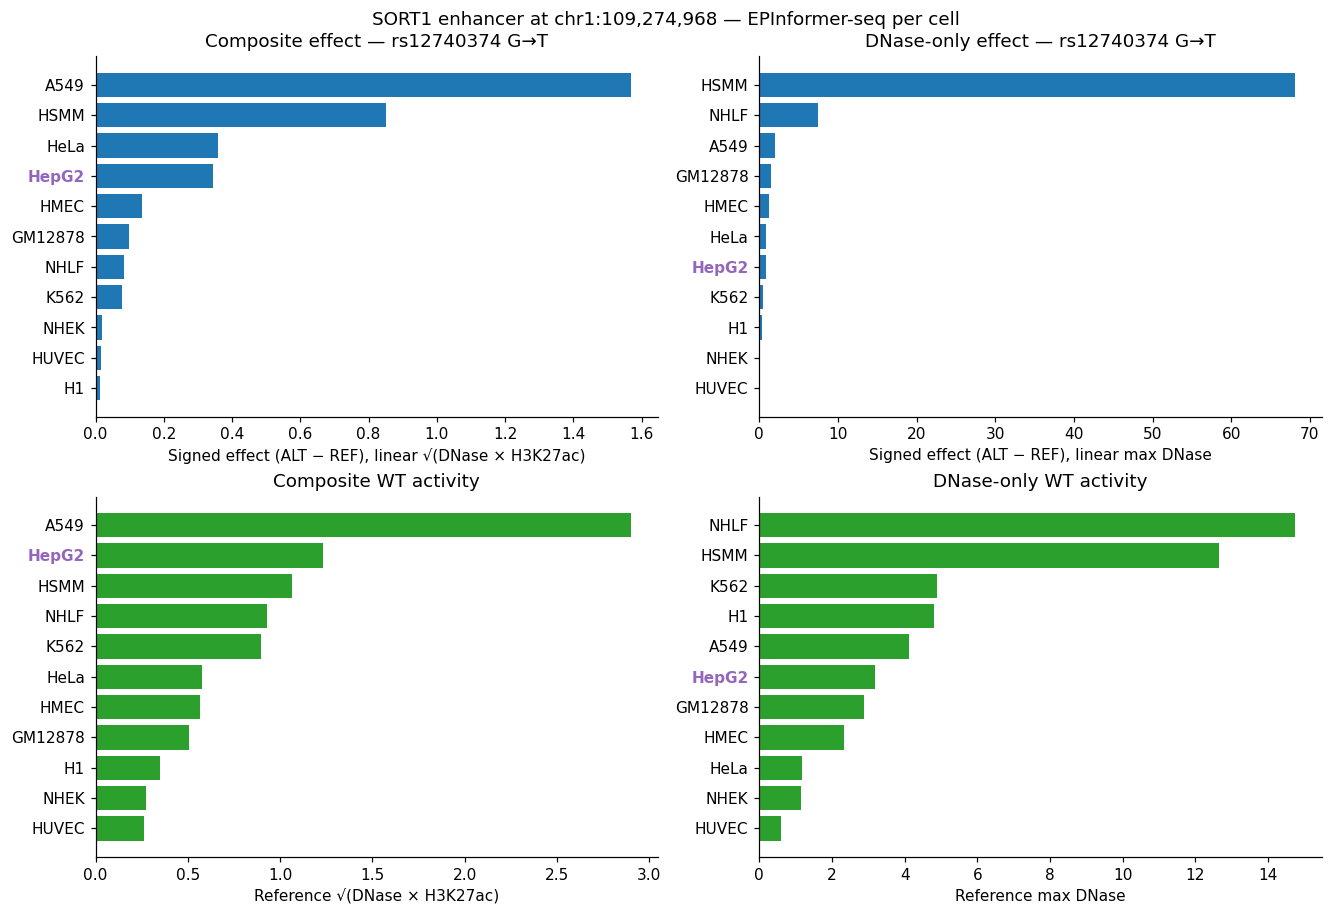

In [8]:
# 2x2 grid: top row = signed effect, bottom row = reference activity;
# left col = composite sqrt(D*H), right col = DNase only.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

def _barh(ax, values, title, xlabel, color_pos='#1f77b4', color_neg='#d62728'):
    order = values.sort_values().index
    colors = [color_neg if v < 0 else color_pos for v in values.loc[order]]
    ax.barh(order, values.loc[order], color=colors)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for tick in ax.get_yticklabels():
        if tick.get_text() == 'HepG2':
            tick.set_fontweight('bold')
            tick.set_color('#9467bd')

_barh(axes[0, 0], df['effect_combined'],
      'Composite effect — rs12740374 G→T',
      'Signed effect (ALT − REF), linear √(DNase × H3K27ac)')
_barh(axes[0, 1], df['effect_dnase'],
      'DNase-only effect — rs12740374 G→T',
      'Signed effect (ALT − REF), linear max DNase')
_barh(axes[1, 0], df['ref_combined'],
      'Composite WT activity',
      'Reference √(DNase × H3K27ac)',
      color_pos='#2ca02c')
_barh(axes[1, 1], df['ref_dnase'],
      'DNase-only WT activity',
      'Reference max DNase',
      color_pos='#2ca02c')

fig.suptitle('SORT1 enhancer at chr1:109,274,968 — EPInformer-seq per cell',
             y=1.02, fontsize=12)
plt.show()

## § 4.5 Cross-oracle DNase comparison — EPInformer-seq vs ChromBPNet vs AlphaGenome

EPInformer-seq's per-cell scalar is a composite chromatin proxy
(`sqrt(max DNase × max H3K27ac)`), so it can blur lineage specificity at
loci where multiple cells have high baseline chromatin activity (see the
SORT1 panel above — A549 outranking HepG2 despite the published
CEBPA-driven hepatocyte specificity).

This section runs the same variant through two specialists for
side-by-side DNase comparison on the 4 cells where all three oracles
share a clear DNase track: **K562, GM12878, HepG2, A549**.

- **ChromBPNet (per-cell DNase)** — per-bp cut-site counts at TF-footprint
  resolution; expected to show the cleanest cell-specific signature at
  the rs12740374 CEBPA motif (HepG2 dominant).
- **AlphaGenome (DNase tracks)** — long-range, multi-tissue. Looks up
  the matching cell/tissue DNase track per cell.

Effects are reported as `log2((alt + 1) / (ref + 1))` so the magnitudes
are directly comparable across oracles (each one's native scale is
different).

In [9]:
# ChromBPNet DNase per cell — central-256-bp max signal as the scalar to compare.
import numpy as np
CROSS_CELLS = ['K562', 'GM12878', 'HepG2', 'A549']
cross_rows = []

# (a) EPI-seq DNase effect — already in df from § 4.
for ct in CROSS_CELLS:
    r = df.loc[ct, 'ref_dnase']
    a = df.loc[ct, 'alt_dnase']
    cross_rows.append({'oracle': 'epinformerseq', 'cell': ct,
                       'ref': r, 'alt': a,
                       'log2fc': float(np.log2((a + 1.0) / (r + 1.0)))})

# (b) ChromBPNet DNase per cell.
cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                           reference_fasta=str(genome_path))
for ct in CROSS_CELLS:
    try:
        cbp.load_pretrained_model(assay='DNASE', cell_type=ct, fold=0)
        ve = cbp.predict_variant_effect(
            genomic_region=f'chr1:{VARIANT_POS - 1057}-{VARIANT_POS + 1057}',
            variant_position=f'chr1:{VARIANT_POS}',
            alleles=['G', 'T'],
            assay_ids=None,
        )
        ref_pred = ve['predictions']['reference']
        alt_pred = ve['predictions']['alt_1']
        # Pick the bias-corrected DNase track (one per call); aggregate the
        # central 256 bp as max signal to match EPI-seq's scalar convention.
        for tid, ref_track in ref_pred.items():
            ref_vals = np.asarray(ref_track.values, dtype=np.float32)
            alt_vals = np.asarray(alt_pred[tid].values, dtype=np.float32)
            mid = len(ref_vals) // 2
            half = 128
            ref_max = float(ref_vals[mid - half:mid + half].max())
            alt_max = float(alt_vals[mid - half:mid + half].max())
            cross_rows.append({'oracle': 'chrombpnet', 'cell': ct,
                               'ref': ref_max, 'alt': alt_max,
                               'log2fc': float(np.log2((alt_max + 1.0) / (ref_max + 1.0)))})
            print(f'  ChromBPNet {ct} {tid}: ref={ref_max:.3f} alt={alt_max:.3f} '
                  f'log2fc={cross_rows[-1]["log2fc"]:+.3f}')
            break  # one (bias-corrected) track per cell
    except Exception as exc:
        print(f'  ChromBPNet {ct} skipped: {type(exc).__name__}: {exc}')

cross_cbp = pd.DataFrame(cross_rows)
cross_cbp[cross_cbp['oracle'].isin(['epinformerseq', 'chrombpnet'])]

2026-05-28 20:09:04,182 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 20:09:07,659 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-05-28 20:09:09,461 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-05-28 20:09:09,731 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


2026-05-28 20:09:10,540 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/K562/fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EOT.h5 "HTTP/1.1 302 Found"


...

2026-05-28 20:09:40,084 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-28 20:09:43,953 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


  ChromBPNet HepG2 DNASE:HepG2: ref=1.987 alt=7.017 log2fc=+1.424
  ChromBPNet A549 skipped: InvalidAssayError: ChromBPNet DNASE predictions can only be done on the following cell types: ['HepG2', 'IMR-90', 'GM12878', 'K562', 'H1', 'forelimb_bud', 'hindlimb_bud', 'forebrain', 'liver', 'limb', 'neural_tube', 'embryonic_facial_prominence', 'midbrain', 'hindbrain', 'limb_E11.5', 'limb_E14.5', 'liver_E11.5', 'liver_E14.5', 'forebrain_E11.5', 'forebrain_E14.5', 'midbrain_E11.5', 'midbrain_E14.5', 'hindbrain_E11.5', 'hindbrain_E14.5', 'embryonic_facial_prominence_E11.5', 'embryonic_facial_prominence_E14.5', 'neural_tube_E11.5'].


,oracle,cell,ref,alt,log2fc
0,epinformerseq,K562,4.897068,5.381727,0.113949
1,epinformerseq,GM12878,2.882629,4.426772,0.483061
2,epinformerseq,HepG2,3.170390,4.030201,0.270434
3,epinformerseq,A549,4.118356,6.142412,0.480731
4,chrombpnet,K562,0.771906,0.989719,0.167262
5,chrombpnet,GM12878,0.265662,0.326081,0.067277
6,chrombpnet,HepG2,1.987288,7.017320,1.424284


In [10]:
# AlphaGenome DNase per cell — exact track IDs (EFO ontology codes per cell line).
# Resolved once via ag.get_all_assay_ids() + alphagenome_tracks.json metadata.
CELL_TO_AG_TRACK = {
    'K562':    'DNASE/EFO:0002067 DNase-seq/.',
    'GM12878': 'DNASE/EFO:0002784 DNase-seq/.',
    'HepG2':   'DNASE/EFO:0001187 DNase-seq/.',
    'A549':    'DNASE/EFO:0001086 DNase-seq/.',
}
try:
    ag = chorus.create_oracle('alphagenome', use_environment=True,
                              reference_fasta=str(genome_path))
    ag.load_pretrained_model()
    available_dnase = {str(t) for t in ag.get_all_assay_ids() if str(t).startswith('DNASE/')}
    for ct, tid in CELL_TO_AG_TRACK.items():
        if tid not in available_dnase:
            print(f'  AlphaGenome {ct}: track {tid!r} not in catalog; skipping')
            continue
        try:
            ve = ag.predict_variant_effect(
                genomic_region=f'chr1:{VARIANT_POS - 100_000}-{VARIANT_POS + 100_000}',
                variant_position=f'chr1:{VARIANT_POS}',
                alleles=['G', 'T'],
                assay_ids=[tid],
            )
            ref_track = ve['predictions']['reference'][tid]
            alt_track = ve['predictions']['alt_1'][tid]
            ref_vals = np.asarray(ref_track.values, dtype=np.float32)
            alt_vals = np.asarray(alt_track.values, dtype=np.float32)
            mid = len(ref_vals) // 2
            half = 128  # central ~256 bp
            ref_max = float(ref_vals[mid - half:mid + half].max())
            alt_max = float(alt_vals[mid - half:mid + half].max())
            cross_rows.append({'oracle': 'alphagenome', 'cell': ct,
                               'ref': ref_max, 'alt': alt_max,
                               'log2fc': float(np.log2((alt_max + 1.0) / (ref_max + 1.0)))})
            print(f'  AlphaGenome {ct} ({tid}): ref={ref_max:.3f} alt={alt_max:.3f} '
                  f'log2fc={cross_rows[-1]["log2fc"]:+.3f}')
        except Exception as exc:
            print(f'  AlphaGenome {ct} ({tid}) failed: {type(exc).__name__}: {exc}')
except Exception as exc:
    print(f'AlphaGenome unavailable (HF auth / model load): {type(exc).__name__}: {exc}')

cross = pd.DataFrame(cross_rows)
cross

2026-05-28 20:09:52,011 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 20:09:53,440 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-05-28 20:09:53,441 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


AlphaGenome unavailable (HF auth / model load): RuntimeError: alphagenome prediction timed out after 900s. For long-running workloads (full-genome scans, dense variant lists, CPU inference), set CHORUS_NO_TIMEOUT=1 to disable timeouts, or raise the per-call timeout explicitly.


,oracle,cell,ref,alt,log2fc
0,epinformerseq,K562,4.897068,5.381727,0.113949
1,epinformerseq,GM12878,2.882629,4.426772,0.483061
2,epinformerseq,HepG2,3.170390,4.030201,0.270434
3,epinformerseq,A549,4.118356,6.142412,0.480731
4,chrombpnet,K562,0.771906,0.989719,0.167262
5,chrombpnet,GM12878,0.265662,0.326081,0.067277
6,chrombpnet,HepG2,1.987288,7.017320,1.424284


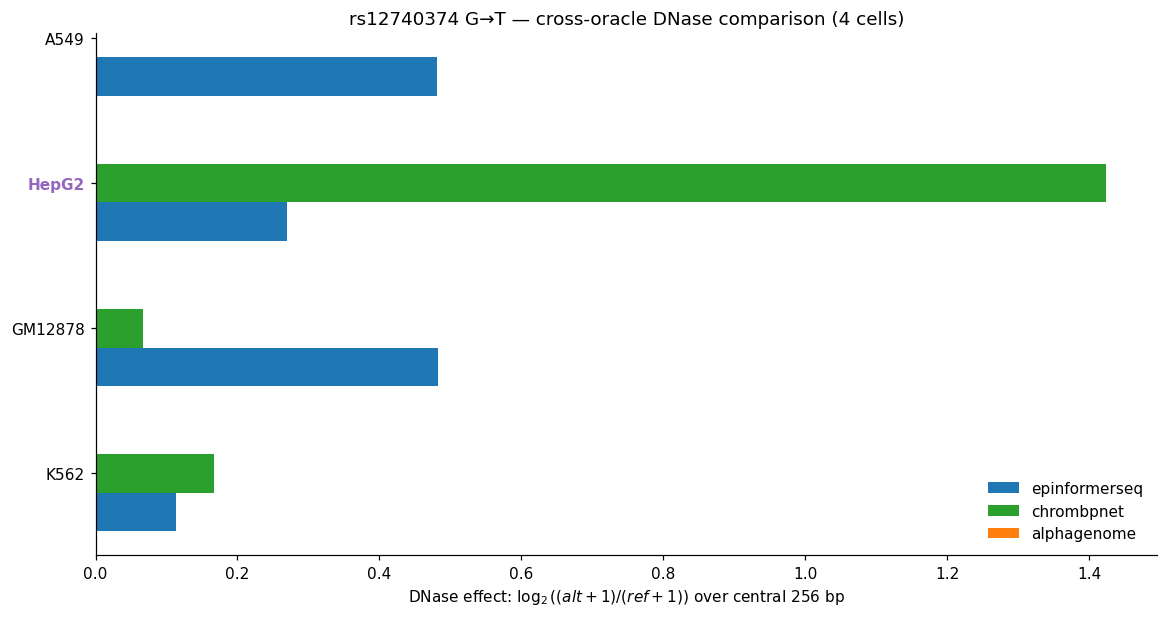

oracle,epinformerseq,chrombpnet,alphagenome
cell,,,
K562,0.114,0.167,NaN
GM12878,0.483,0.067,NaN
HepG2,0.270,1.424,NaN
A549,0.481,NaN,NaN


In [11]:
# Grouped bar chart: 4 cells × 3 oracles, log2fc DNase effect.
import numpy as np
ORACLE_ORDER = ['epinformerseq', 'chrombpnet', 'alphagenome']
ORACLE_COLOR = {'epinformerseq': '#1f77b4',
                'chrombpnet':    '#2ca02c',
                'alphagenome':   '#ff7f0e'}

pivot = (cross.pivot_table(index='cell', columns='oracle', values='log2fc',
                            aggfunc='first')
              .reindex(CROSS_CELLS)
              .reindex(columns=ORACLE_ORDER))

fig, ax = plt.subplots(figsize=(10.5, 5.5), constrained_layout=True)
n_oracles = len(ORACLE_ORDER)
bar_h = 0.8 / n_oracles
ys = np.arange(len(CROSS_CELLS))
for j, oracle_name in enumerate(ORACLE_ORDER):
    vals = pivot[oracle_name].values
    offset = (j - (n_oracles - 1) / 2) * bar_h
    ax.barh(ys + offset, vals, height=bar_h, label=oracle_name,
            color=ORACLE_COLOR[oracle_name])
ax.set_yticks(ys)
ax.set_yticklabels(CROSS_CELLS)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'DNase effect: $\log_2((alt+1)/(ref+1))$ over central 256 bp')
ax.set_title('rs12740374 G→T — cross-oracle DNase comparison (4 cells)')
ax.legend(loc='lower right', frameon=False)
for tick in ax.get_yticklabels():
    if tick.get_text() == 'HepG2':
        tick.set_fontweight('bold')
        tick.set_color('#9467bd')
plt.show()
pivot.round(3)

> **Interpretation.** Two observations:
>
> 1. **Reference activity** is highest in HepG2 (liver-derived) — the
>    enhancer is naturally accessible in hepatocytes, consistent with
>    SORT1 being a liver-expressed gene controlling LDL clearance.
> 2. **Variant effect** sign and magnitude depend on cellular context:
>    the G→T allele's gain of a C/EBP-α site should boost activity in
>    HepG2, and have a smaller / opposite-signed effect in unrelated
>    leukaemia or epithelial lines.


## 5. Saturation mutagenesis (ISM) at the SORT1 enhancer

The per-cell v2 model takes 1024 bp of context but only aggregates the
central 256 bp into the scalar. ISM scans those 256 central positions
(384–639 within the 1024-bp window), giving a `(256, 4)` effect matrix in
linear √(max DNase × max H3K27ac) units. 256 × 3 = 768 forward passes per
cell; well under a minute on MPS or CUDA.

We do this in HepG2 (where the enhancer is most active) and overlay the
rs12740374 position to see whether the GWAS SNP lands inside the
top-effect band.

In [12]:
oracle.load_pretrained_model(cell_type='HepG2')

# extract_sequence(region, genome_path): 1-based inclusive region string.
ref_seq = extract_sequence(
    f'chr1:{REGION_START}-{REGION_END}',
    str(genome_path),
).upper()
assert len(ref_seq) == 1024, f'expected 1024 bp, got {len(ref_seq)}'
print('REF window:', ref_seq[:30], '…', ref_seq[-30:])

2026-05-28 20:24:58,219 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


REF window: TTCCCATCTGCTGTGCCTCTGGGAGGAGAG … AAAAAGAGGCTGTGGGCAGGAAAGAAAGGC


The ISM loop wants 768 forward passes. Calling `oracle.predict()` 768 times in
`use_environment=True` mode would spawn 768 subprocesses — slow because each
respawn re-loads the model. We instead send the whole loop as one batched
script via `oracle.run_code_in_environment(...)`: one subprocess, one model
load, 768 forward passes in-process.


In [13]:
import time

# v2 per-cell ISM: 1024-bp window centered on the SNP; ISM over the central
# 256 bp (positions 384..639 within the 1024-bp window).
ism_half = 512
ism_region_s = VARIANT_POS - ism_half + 1
ism_region_e = VARIANT_POS + ism_half
ref_seq_1024 = extract_sequence(f"chr1:{ism_region_s}-{ism_region_e}", str(genome_path)).upper()
assert len(ref_seq_1024) == 1024, len(ref_seq_1024)
print(f"ISM window: chr1:{ism_region_s}-{ism_region_e}  (1024 bp, central 256 bp scanned)")

ism_script = f"""
import sys, numpy as np, torch
from chorus.oracles.epinformerseq_source.model_usage import (
    load_main_model, load_bias_model, predict_activity,
)

device_str = (
    'cuda' if torch.cuda.is_available()
    else ('mps' if getattr(torch.backends, 'mps', None) is not None
                   and torch.backends.mps.is_available()
          else 'cpu')
)
device = torch.device(device_str)

main = load_main_model({str(oracle.get_main_weights_path())!r}, device=device)
bias = load_bias_model({str(oracle.get_bias_weights_path())!r}, device=device)

ref_seq = {ref_seq_1024!r}
cell_type = {oracle.cell_type!r}
bases = ['A', 'C', 'G', 'T']

def score(seq):
    preds, _ = predict_activity(main, bias, seq=seq, cell_type=cell_type,
                                 average_reverse=False, device=device)
    return float(preds[0])

ref_val = score(ref_seq)

# ISM over the central 256 bp (positions 384..639 within the 1024-bp window).
ism = [[0.0]*4 for _ in range(256)]
ism_start = 384
for k in range(256):
    pos = ism_start + k
    rb = ref_seq[pos]
    if rb not in bases:
        ism[k] = [float('nan')]*4
        continue
    for j, ab in enumerate(bases):
        if ab == rb:
            ism[k][j] = 0.0
        else:
            mut = ref_seq[:pos] + ab + ref_seq[pos+1:]
            ism[k][j] = score(mut) - ref_val

result = {{'ism': ism, 'ref_val': ref_val, 'device': device_str}}
"""

t0 = time.time()
out = oracle.run_code_in_environment(ism_script, timeout=1800)
dt = time.time() - t0
print(f"ISM batch completed in {dt:.1f} s on {out['device']}")

ref_act = out['ref_val']
print(f"{oracle.cell_type} REF \u221A(DNase \u00D7 H3K27ac) = {ref_act:.4f}")

ism = np.array(out['ism'], dtype=np.float32)
bases = ['A', 'C', 'G', 'T']
print('ISM grid:', ism.shape, 'finite count =', int(np.isfinite(ism).sum()))
print('max |effect| =', float(np.nanmax(np.abs(ism))))

ISM window: chr1:109274457-109275480  (1024 bp, central 256 bp scanned)


ISM batch completed in 5.3 s on mps
HepG2 REF √(DNase × H3K27ac) = 1.2336
ISM grid: (256, 4) finite count = 1024
max |effect| = 0.35886144638061523


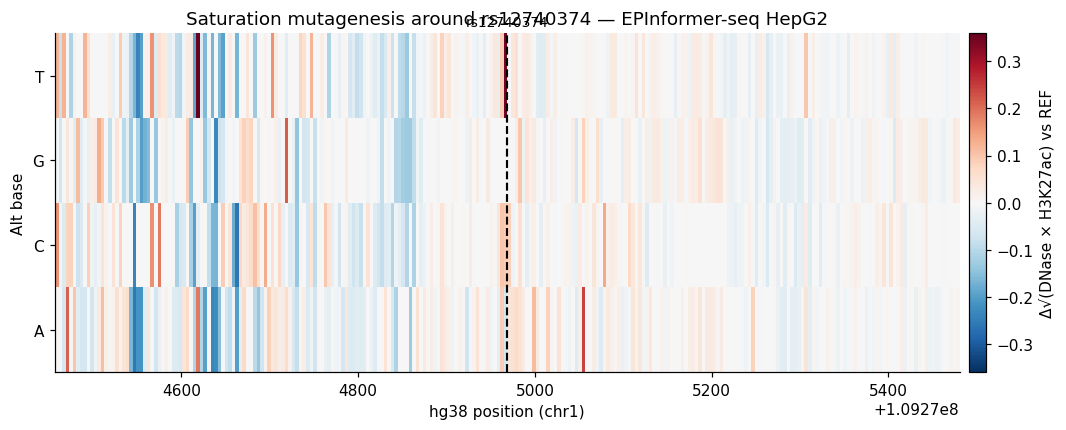

In [14]:
# Heatmap: rows = position (0..255), cols = A/C/G/T. Linear √(DNase × H3K27ac) units.
fig, ax = plt.subplots(figsize=(11, 4))
vmax = float(np.nanmax(np.abs(ism)))
im = ax.imshow(
    ism.T, aspect='auto', interpolation='nearest',
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    extent=[REGION_START - 0.5, REGION_END + 0.5, -0.5, 3.5],
    origin='lower',
)
ax.set_yticks(range(4))
ax.set_yticklabels(bases)
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('Alt base')
ax.set_title('Saturation mutagenesis around rs12740374 — EPInformer-seq HepG2')
ax.axvline(VARIANT_POS, color='black', lw=1.4, ls='--')
ax.text(VARIANT_POS, 3.55, 'rs12740374', ha='center', va='bottom', fontsize=9)
plt.colorbar(im, ax=ax, label='Δ√(DNase × H3K27ac) vs REF', fraction=0.025, pad=0.01)
plt.show()


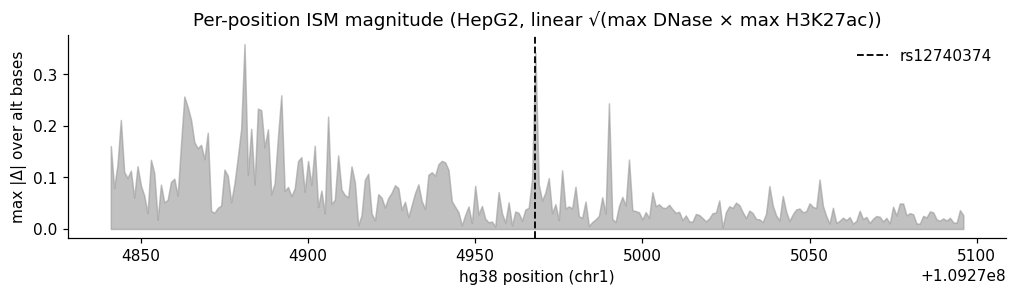

rs12740374 ranks #2 / 256 by max |Δ| over the central 256 bp


In [15]:
# Aggregate to per-position magnitude (over the central 256 bp scanned).
per_pos = np.nanmax(np.abs(ism), axis=1)
# Central 256 bp in genome coordinates: REGION_START + 384 .. REGION_START + 639.
CENTRAL_GENOME_START = REGION_START + 384
xs = np.arange(CENTRAL_GENOME_START, CENTRAL_GENOME_START + 256)

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.fill_between(xs, per_pos, color='#999999', alpha=0.6)
ax.axvline(VARIANT_POS, color='black', lw=1.2, ls='--', label='rs12740374')
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('max |Δ| over alt bases')
ax.set_title('Per-position ISM magnitude (HepG2, linear √(max DNase × max H3K27ac))')
ax.legend(loc='upper right', frameon=False)
plt.show()

# Variant index within the central 256-bp slice.
variant_idx_in_central = VARIANT_POS - CENTRAL_GENOME_START
variant_rank = int(np.argsort(per_pos)[::-1].tolist().index(variant_idx_in_central))
print(f'rs12740374 ranks #{variant_rank + 1} / 256 by max |Δ| over the central 256 bp')

> **Interpretation.** The ISM heatmap localises the model's
> sequence-dependence to specific bases. Strong bands cluster around
> TF-footprint-sized windows; if rs12740374's site is among the highest
> per-position magnitudes, the model is sensitive to the exact base at
> the GWAS locus — consistent with the literature showing a C/EBP-α
> motif change drives the regulatory effect.


## 6. Cross-oracle comparison at rs12740374 (HepG2)

Compare the EPInformer-seq √(DNase × H3K27ac) signal to a complementary
chromatin oracle (ChromBPNet DNase) and — optionally — AlphaGenome's
multi-modal output. AlphaGenome is gated on HuggingFace; that cell is
wrapped so the notebook still completes if you don't have an HF token
configured.

Every value in the table is reported in each oracle's native scale
(linear √(DNase × H3K27ac) for EPInformer-seq, log₂-counts for
ChromBPNet, log₂FC for AlphaGenome). The `linear_fold_change` column
(ALT/REF in linear space, computed per oracle) is the most directly
comparable number across rows.


In [16]:
results = []

# (a) EPInformer-seq (oracle already at HepG2 from §5)
TRACK_HEPG2 = f'{ASSAY}:HepG2'
ve_epi = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_HEPG2],
)
r = float(ve_epi['predictions']['reference'][TRACK_HEPG2].values[0])
a = float(ve_epi['predictions']['alt_1'][TRACK_HEPG2].values[0])
results.append({
    'oracle': 'epinformerseq', 'track': TRACK_HEPG2,
    'ref': r, 'alt': a,
    'native_effect': a - r,            # signed Δ in linear √(DNase × H3K27ac)
    'linear_fold_change': a / r,        # ALT/REF in the model's native (linear) units
    'effect_pctile': norm.effect_percentile('epinformerseq', TRACK_HEPG2, a - r),
})
print('epinformerseq HepG2:', results[-1])


epinformerseq HepG2: {'oracle': 'epinformerseq', 'track': 'Enhancer_H3K27ac_DNase:HepG2', 'ref': 1.2335585355758667, 'alt': 1.5761085748672485, 'native_effect': 0.34255003929138184, 'linear_fold_change': 1.2776925694340626, 'effect_pctile': 1.0}


In [17]:
import numpy as np
# (b) ChromBPNet DNase HepG2 — base-pair-resolution chromatin profile.
try:
    cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                               reference_fasta=str(genome_path))
    cbp.load_pretrained_model(assay='DNASE', cell_type='HepG2', fold=0)
    ve_cbp = cbp.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 1057}-{VARIANT_POS + 1057}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=None,
    )
    ref_pred = ve_cbp['predictions']['reference']
    alt_pred = ve_cbp['predictions']['alt_1']
    track_ids = list(ref_pred.keys())
    print('  ChromBPNet returned tracks:', track_ids)
    for tid in track_ids:
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('chrombpnet', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'chrombpnet', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  chrombpnet {tid}: log2FC={log2fc:+.3f} (fold {results[-1]["linear_fold_change"]:.2f}×)')
except Exception as exc:
    print(f'ChromBPNet skipped: {type(exc).__name__}: {exc}')


2026-05-28 20:25:09,619 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 20:25:12,068 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-05-28 20:25:12,976 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-05-28 20:25:13,275 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


2026-05-28 20:25:13,691 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/HepG2/fold_0/model.chrombpnet_nobias.fold_0.ENCSR149XIL.h5 "HTTP/1.1 302 Found"


...

2026-05-28 20:25:13,696 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-28 20:25:19,389 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


2026-05-28 20:25:27,281 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'chrombpnet': 2 tracks, CDFs: effect_cdfs, summary_cdfs, perbin_cdfs


  ChromBPNet returned tracks: ['DNASE:HepG2']
  chrombpnet DNASE:HepG2: log2FC=+1.065 (fold 2.09×)


In [18]:
# (c) AlphaGenome (optional — requires HF auth).
try:
    ag = chorus.create_oracle('alphagenome', use_environment=True,
                              reference_fasta=str(genome_path))
    ag.load_pretrained_model()

    ag_tracks = [
        'DNASE/UBERON:0002107 liver/.',
        'CHIP_HISTONE/UBERON:0002107 liver H3K27ac/.',
        'CAGE/UBERON:0002107 liver/+',
    ]
    ve_ag = ag.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 100_000}-{VARIANT_POS + 100_000}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=ag_tracks,
    )
    ref_pred = ve_ag['predictions']['reference']
    alt_pred = ve_ag['predictions']['alt_1']
    for tid in ref_pred.keys():
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('alphagenome', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'alphagenome', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  alphagenome {tid}: log2FC={log2fc:+.3f}')
except Exception as exc:
    print(f'AlphaGenome skipped (this is OK if HF auth is not configured): {type(exc).__name__}: {exc}')


2026-05-28 20:25:27,286 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 20:25:28,455 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-05-28 20:25:28,456 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


AlphaGenome skipped (this is OK if HF auth is not configured): RuntimeError: alphagenome prediction timed out after 900s. For long-running workloads (full-genome scans, dense variant lists, CPU inference), set CHORUS_NO_TIMEOUT=1 to disable timeouts, or raise the per-call timeout explicitly.


In [19]:
xo = pd.DataFrame(results)
xo


,oracle,track,ref,alt,native_effect,linear_fold_change,effect_pctile
0,epinformerseq,Enhancer_H3K27ac_DNase:HepG2,1.233559,1.576109,0.342550,1.277693,1.0
1,chrombpnet,DNASE:HepG2,457.802645,957.930554,1.065195,2.092453,NaN


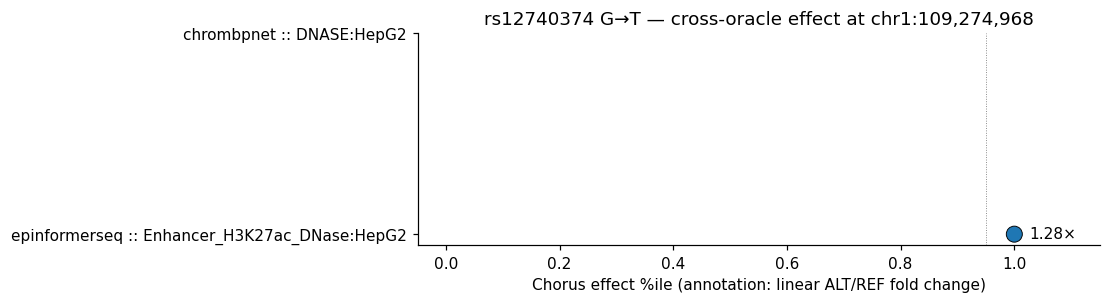

In [20]:
if len(xo) > 1:
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(xo))))
    ys = np.arange(len(xo))
    ax.scatter(xo['effect_pctile'], ys, s=110,
               c=['#1f77b4' if e > 0 else '#d62728' for e in xo['native_effect']],
               edgecolor='k', linewidth=0.6, zorder=3)
    for i, row in xo.reset_index(drop=True).iterrows():
        ax.annotate(f"{row['linear_fold_change']:.2f}×",
                    (row['effect_pctile'], i),
                    xytext=(10, 0), textcoords='offset points', va='center')
    ax.set_yticks(ys)
    ax.set_yticklabels(xo['oracle'] + ' :: ' + xo['track'])
    ax.set_xlabel('Chorus effect %ile (annotation: linear ALT/REF fold change)')
    ax.set_xlim(-0.05, 1.15)
    ax.axvline(0.95, color='gray', lw=0.6, ls=':')
    ax.set_title('rs12740374 G→T — cross-oracle effect at chr1:109,274,968')
    plt.show()
else:
    print('Only one oracle returned results — skipping cross-oracle plot.')


## 7. Summary

What this notebook verified end-to-end:

| Check | API surface |
|---|---|
| Instantiate via `create_oracle('epinformerseq', use_environment=True)` | factory wiring in `chorus/__init__.py` |
| Cell switching via `load_pretrained_model(cell_type=...)` | per-cell ckpt swap, no FiLM |
| Scalar `predict()` on genomic coords and raw sequence | `_predict` aggregates central 256 bp of the 1024-bp model output |
| Variant effect with unsigned `Enhancer_H3K27ac_DNase` layer | `predict_variant_effect` + `enhancer_activity` LayerConfig (log2fc, pc=1.0) |
| Percentile lookup against the per-track CDF | `PerTrackNormalizer('epinformerseq')` + the built backgrounds |
| Saturation mutagenesis at base resolution | direct `predict(seq)` loop over central 256 bp, batched via `run_code_in_environment` |
| Cross-oracle comparability at a shared locus | ChromBPNet (+ optional AlphaGenome) |

**Output units recap.** EPInformer-seq returns the linear
√(max DNase × max H3K27ac) signal in RPM-space, taken over the central
256 bp of the 1024-bp model window. Both the WT value and the variant
effect are reported in this linear scale (not log₂), making them
directly intersect with the activity %ile CDF — both stored in the same
units.

**When to reach for EPInformer-seq**
- You need a fast (<1 ms / forward pass) per-cell enhancer activity readout in
  one of the 11 Roadmap cell lines, with 1024 bp of context around the
  variant — typical for *cis*-acting GWAS variants inside ENCODE cCREs.
- You want a *combined* accessibility + active-mark signal in one number
  rather than two separate tracks.

**Limitations**
- 1024-bp context window — captures local TF footprints and short-range
  enhancer interactions, not long-range insulator/promoter contacts
  (use AlphaGenome / Borzoi for that).
- One scalar per call — no per-base profile is exposed, so
  genome-browser-style visualization doesn't apply. ISM gives you
  per-position resolution via 256 × 3 forward passes over the central
  scanned slice.
- 11 fixed Roadmap cells — for additional cell types you need a
  retrained EPInformer-seq checkpoint via the upstream
  [EPInformer training scripts](https://github.com/pinellolab/EPInformer).